# Extracting datasets to do specialised plots

## Description
giwaxs_toolbox also has functions to extract the 1d or 2d datasets from i07 processed files which can then be used in personalised plots

first create a data loader using the following syntax:

```python
from giwaxs_toolbox.processing import data_loader
loader =  data_loader(datafolder='path/to/your/data')
```

Once you have a data loader for your data folder you can extract a series of datasets using the syntax:

```python
filelist=['file1','file2','file3']
results= loader.loadfiles(filelist)
```

This will then give you a list of your datasets, each of which will either be of the type result1d or result2d. These result objects have the following attributes:

result1d

```python
result1d.data  # the one dimensional profile data
result1d.x_axis # the axis data for the x-axis
```

result2d

```python
result2d.data   # the two dimensional image data
result2d.x_axis # the axis data for the x-axis
result2d.y_axis # the axis data for the y-axis
```

# Load in 1d datasets

In [2]:
from giwaxs_toolbox.processing import data_loader
from giwaxs_toolbox.plotting import reset_plots
import matplotlib.pyplot as plt
from pprint import pprint
import numpy as np
import os

In [6]:
folder1="/dls/science/groups/das/ExampleData/i07/fast_rsm_example_data/tests_versioned/v2.4.1_i07_2026-04-14"
filelist= [file for file in os.listdir(folder1) if file.endswith('.hdf5')]

#create your data loader for your data directory path
loader=data_loader(datafolder=folder1)

#choose which datasets you want to load

example_ivqfiles=['IvsQ_432196_2026-04-14_14h19m06s.hdf5',
                  'IvsQ_610009_2026-04-14_14h22m41s.hdf5']

# load the files into a results object
ivqresults=loader.loadfiles(example_ivqfiles,index1vals= np.arange(0,100,10))

You can then use the results objects in your plotting routines, as shown below using the attributes '.x_axis' and '.data'

<function matplotlib.pyplot.show(block=None)>

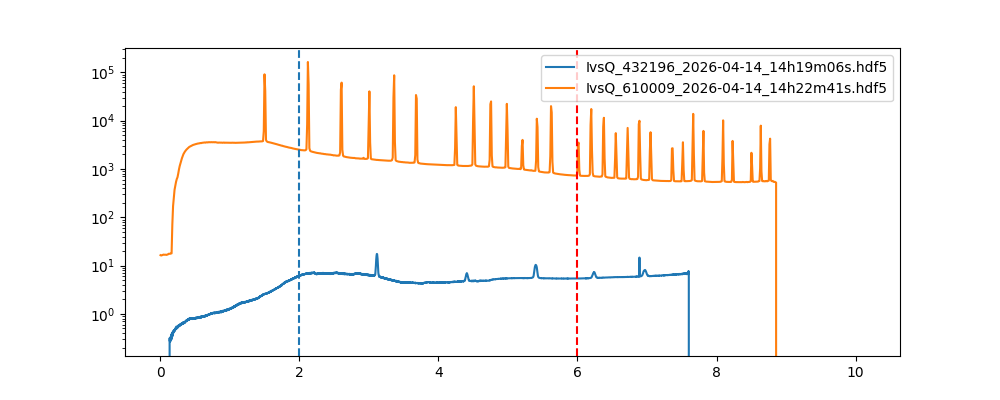

In [7]:
#set interactive ipympl
%matplotlib ipympl

#create your figure
fig,axs=plt.subplots(figsize=(10,4))

#use the result objects from the results list to plot onto the graph
for num,res in enumerate(ivqresults):
    axs.semilogy(res.x_axis,res.data,label=example_ivqfiles[num])

axs.axvline(2,ls='--')
axs.axvline(6,ls='--',color='red')
plt.legend()
plt.show

This will give the example plot 

![image2.png](../images/bespoke_ivsq.png)

## loading in 2d datasets
You can do the same process for 2d datasets as well, below is an example using the result2d objects along with extra plotting shapes for customised plots

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Annulus, Wedge


#create your data loader for your data directory path, note if the 2d datasets are in the same folder as the 1d datasets the loader from the previous section can be reused
loader=data_loader(datafolder=folder1)


#choose which datasets you want to load
exitmap_filenames=['exitmap_432196_2026-04-14_14h19m03s.hdf5','exitmap_610009_2026-04-14_14h22m49s.hdf5']

# load the files into a results object
exitmapresults=loader.loadfiles(exitmap_filenames)

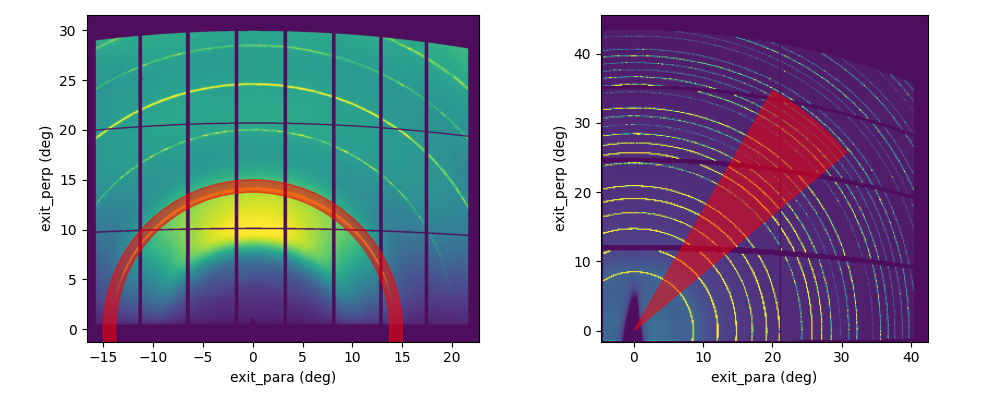

In [12]:
fig,axs=plt.subplots(1,2,figsize=(10,4))

axlist=axs.flatten()
for i,res in enumerate(exitmapresults):
    maplimits=[res.x_axis.min(), res.x_axis.max(), res.y_axis.min(),res.y_axis.max()]
    map2d=res.data
    axlist[i].imshow(map2d,vmax=map2d.mean()+2*map2d.std(),extent=maplimits,alpha=0.95)
    #axlist[i].set_aspect('equal')
    axlist[i].set_xlabel('exit_para (deg)')
    axlist[i].set_ylabel('exit_perp (deg)')

selection_ring=Annulus((0,0), 15, 1.25,color='red',alpha=0.55)
selection_wedge = Wedge((0.0),40,40,60,color='red',alpha=0.5)
axlist[0].add_patch(selection_ring)
axlist[1].add_patch(selection_wedge)
plt.tight_layout()
plt.show()

Similar to the previous example this will output a specialised using the loaded data result objects

![image4.png](../images/bespoke_qmap.png)
